Chapter 26
# 可视化二元高斯分布PDF
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal #多元高斯分布

##图像
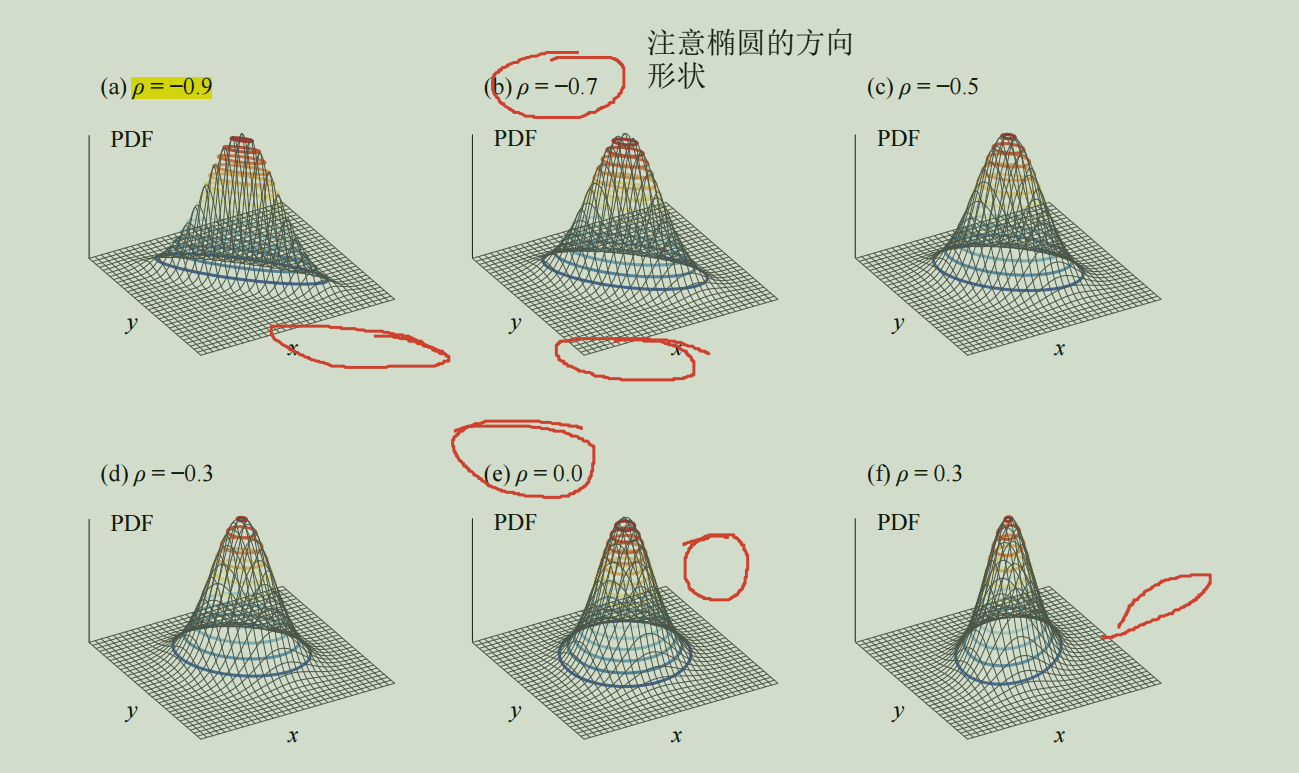

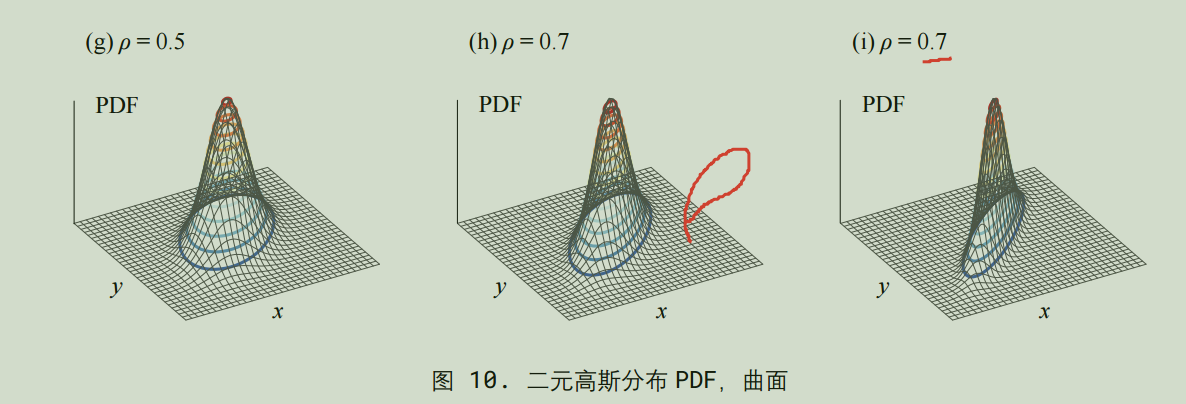

In [13]:
rho_array = [-0.9, -0.7, -0.5, -0.3,
             0, 0.3, 0.5, 0.7, 0.9]
# 相关性系数

In [14]:
sigma_X = 1; sigma_Y = 1 # 标准差

把两个期望值写成质心向量 [µX，µY]。注意，这个向量是个行向量，而代码 5 给出公式中质心
向量 µ 为列向量。

In [15]:
mu_X = 0;    mu_Y = 0    # 期望

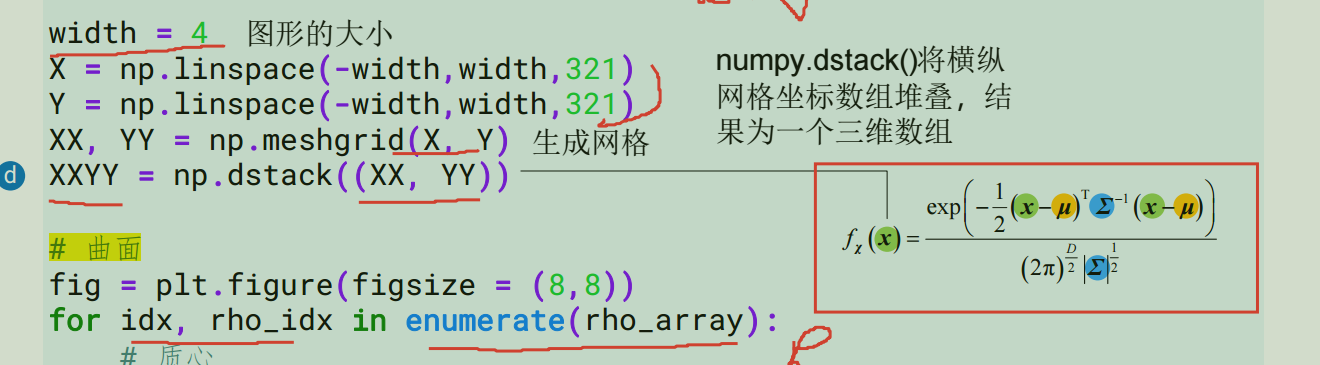

In [16]:
width = 4
X = np.linspace(-width,width,321) #图像的大小
Y = np.linspace(-width,width,321)
XX, YY = np.meshgrid(X, Y)  # 生成网格
XXYY = np.dstack((XX, YY))   #numpy.dstack()将横纵网格坐标数组堆叠，结果为一个三维数组

In [5]:
XX  # 行方向

array([[-4.   , -3.975, -3.95 , ...,  3.95 ,  3.975,  4.   ],
       [-4.   , -3.975, -3.95 , ...,  3.95 ,  3.975,  4.   ],
       [-4.   , -3.975, -3.95 , ...,  3.95 ,  3.975,  4.   ],
       ...,
       [-4.   , -3.975, -3.95 , ...,  3.95 ,  3.975,  4.   ],
       [-4.   , -3.975, -3.95 , ...,  3.95 ,  3.975,  4.   ],
       [-4.   , -3.975, -3.95 , ...,  3.95 ,  3.975,  4.   ]])

In [6]:
YY # 从小到大； 列方向

array([[-4.   , -4.   , -4.   , ..., -4.   , -4.   , -4.   ],
       [-3.975, -3.975, -3.975, ..., -3.975, -3.975, -3.975],
       [-3.95 , -3.95 , -3.95 , ..., -3.95 , -3.95 , -3.95 ],
       ...,
       [ 3.95 ,  3.95 ,  3.95 , ...,  3.95 ,  3.95 ,  3.95 ],
       [ 3.975,  3.975,  3.975, ...,  3.975,  3.975,  3.975],
       [ 4.   ,  4.   ,  4.   , ...,  4.   ,  4.   ,  4.   ]])

## 数据类型为 321,321,2； 每个二维数组就是321个点

In [7]:
XXYY  # 数据类型为 321,321,2； 每个二维数组就是321个点

array([[[-4.   , -4.   ],
        [-3.975, -4.   ],
        [-3.95 , -4.   ],
        ...,
        [ 3.95 , -4.   ],
        [ 3.975, -4.   ],
        [ 4.   , -4.   ]],

       [[-4.   , -3.975],
        [-3.975, -3.975],
        [-3.95 , -3.975],
        ...,
        [ 3.95 , -3.975],
        [ 3.975, -3.975],
        [ 4.   , -3.975]],

       [[-4.   , -3.95 ],
        [-3.975, -3.95 ],
        [-3.95 , -3.95 ],
        ...,
        [ 3.95 , -3.95 ],
        [ 3.975, -3.95 ],
        [ 4.   , -3.95 ]],

       ...,

       [[-4.   ,  3.95 ],
        [-3.975,  3.95 ],
        [-3.95 ,  3.95 ],
        ...,
        [ 3.95 ,  3.95 ],
        [ 3.975,  3.95 ],
        [ 4.   ,  3.95 ]],

       [[-4.   ,  3.975],
        [-3.975,  3.975],
        [-3.95 ,  3.975],
        ...,
        [ 3.95 ,  3.975],
        [ 3.975,  3.975],
        [ 4.   ,  3.975]],

       [[-4.   ,  4.   ],
        [-3.975,  4.   ],
        [-3.95 ,  4.   ],
        ...,
        [ 3.95 ,  4.   ],
        [ 3.975

In [8]:
XXYY.shape

(321, 321, 2)

In [9]:
print(type(XXYY))

<class 'numpy.ndarray'>


a
用列表定义了一组相关性系数取值。

b
定义了两个随机变量各自的标准差——σX、σY。

c
则定义了两个随机变量的期望值——µX、µY。

d
用 numpy.dstack()将横纵网格坐标数组堆叠，结果为一个三维数组
。

e
把两个期望值写成质心向量 [µX，µY]。注意，这个向量是个行向量，而代码 5 给出公式中质心
向量 µ 为列向量。


f
用相关性系数、标准差构造协方差矩阵 (covariance matrix)

g
利用 scipy.stats 中的 multivariate_normal 对象，构造二元高斯分布对象实例
bi_norm。这个函数的输入为刚刚创建的质心向量、协方差矩阵。

h
利用 bi_norm 的 pdf()方法生成概率密度函数值 fX,Y(x,y)。这个方法的输入为

d

生成的三维数
组，代表一组网格坐标点。

i
在三维轴对象 ax 上用 plot_wireframe()绘制三维网格曲面。

j
在三维轴对象 ax 上用 contour()再绘制一个三维等高线。

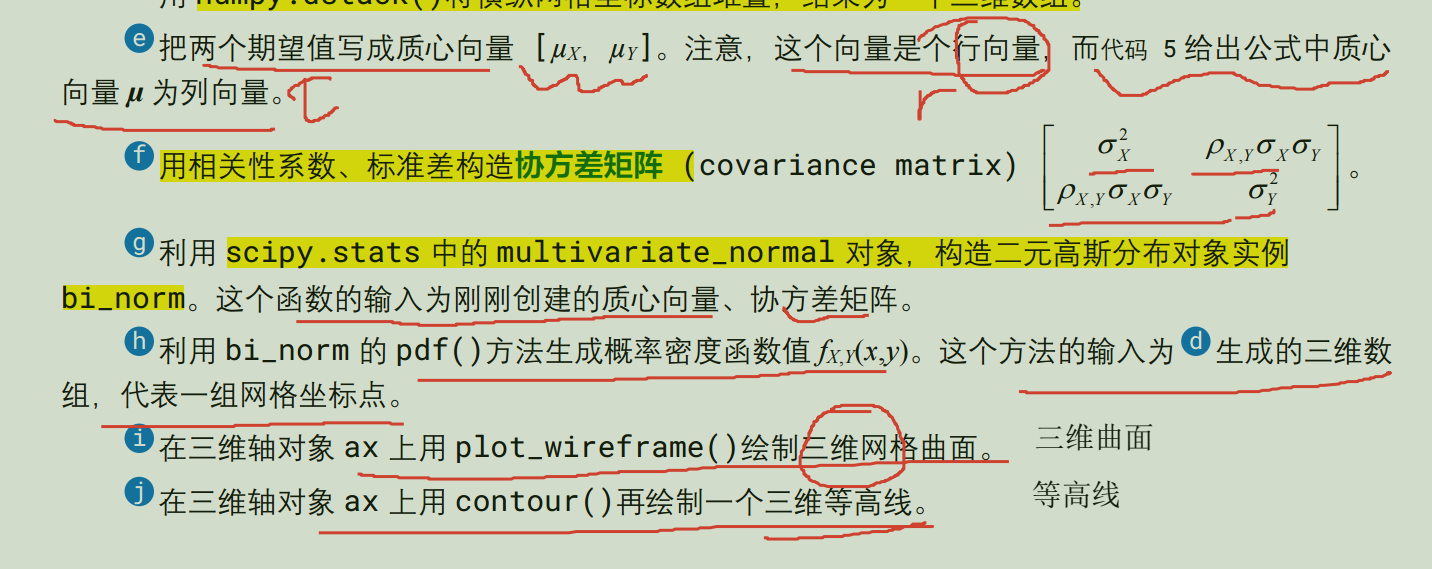

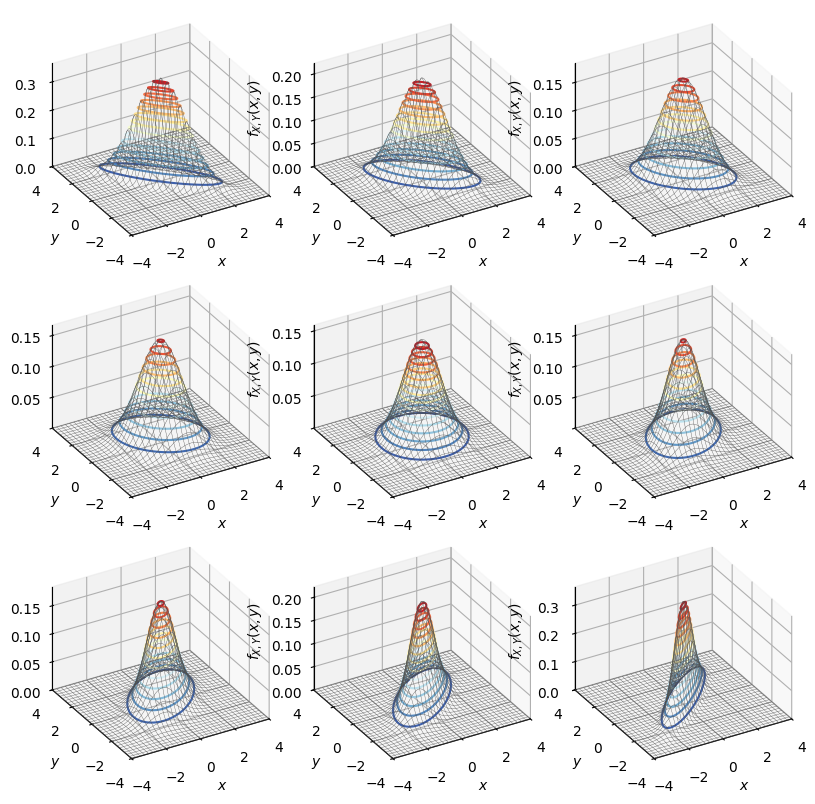

In [17]:
# 曲面
fig = plt.figure(figsize = (8,8))
for idx, rho_idx in enumerate(rho_array):  # 索引：数值
    # 质心
    mu    = [mu_X, mu_Y]
    # 协方差  矩阵
    Sigma = [[sigma_X**2, sigma_X*sigma_Y*rho_idx],
            [sigma_X*sigma_Y*rho_idx, sigma_Y**2]]
    # 二元高斯分布
    bi_norm = multivariate_normal(mu, Sigma) #多元高斯分布
    f_X_Y_joint = bi_norm.pdf(XXYY) # 根据点得出结果
    # .pdf(XXYY)：一次性计算网格上所有点的概率密度值，返回形状为 (321, 321) 的矩阵。

    ax = fig.add_subplot(3,3,idx+1,projection='3d') # 3d

    '''
    plot_wireframe：绘制线框曲面图（灰色，较稀疏）
    rstride=10, cstride=10：行和列每隔 10 个点取一条线，减少线条密度，避免过密。
    contour：在曲面底部绘制等高线投影，15 条等高线，颜色映射为 RdYlBu_r（红-黄-蓝，反向）
    '''
    # 生成曲面
    ax.plot_wireframe(XX, YY, f_X_Y_joint,  # xyz
                      rstride=10, cstride=10,
                      color = [0.3,0.3,0.3],
                      linewidth = 0.25)
    # 生成等高线
    ax.contour(XX,YY, f_X_Y_joint,15,
               cmap = 'RdYlBu_r')

    ax.set_xlabel('$x$'); ax.set_ylabel('$y$') #标签
    ax.set_zlabel('$f_{X,Y}(x,y)$')
    ax.view_init(azim=-120, elev=30) #视角
    ax.set_proj_type('ortho') # 正交投影

    '''
      view_init：设置 3D 观察角度，让所有子图的视角一致，便于对比。
    ortho：正交投影，保持物体大小不随距离变化。
    '''

    ax.set_xlim(-width, width); ax.set_ylim(-width, width)
    ax.set_zlim(f_X_Y_joint.min(),f_X_Y_joint.max())
    # ax.axis('off')

plt.tight_layout()  # # 自动调整子图间距
# fig.savefig('二元高斯分布，曲面.svg', format='svg')
plt.show()

##将图 10 投影到水平面，如图 11 所示，我们惊奇地发现这些曲面的等高线是椭圆！似乎相关系系数影响着椭圆的旋转角度。

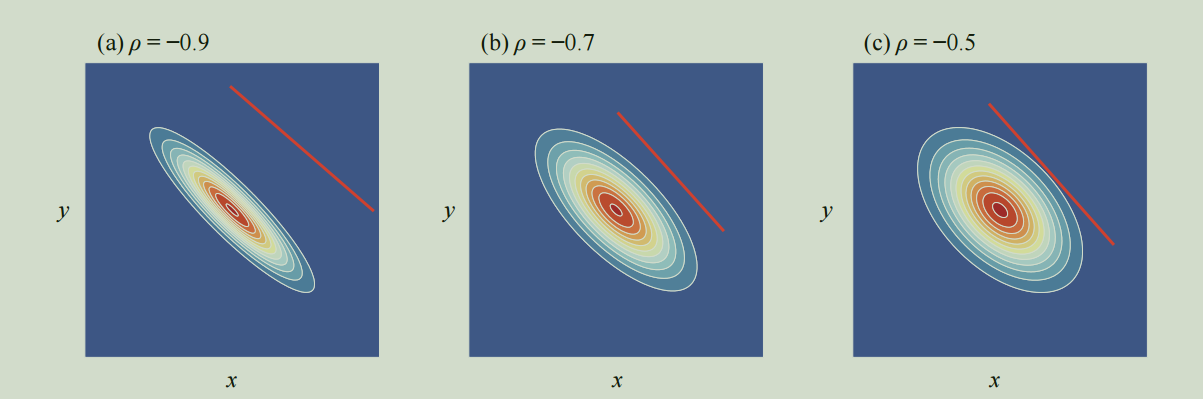

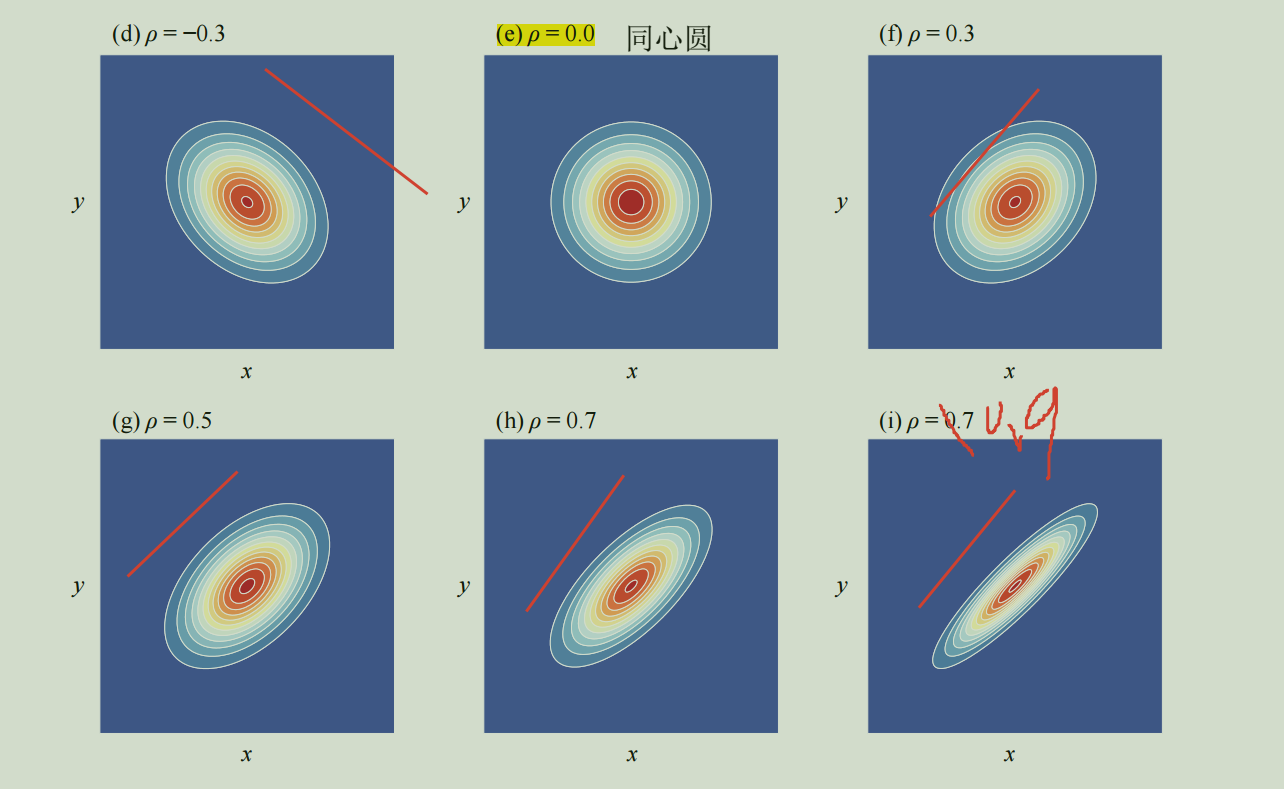

利用 bi_norm 的 pdf()方法生成概率密度函数值 fX,Y(x,y)。这个方法的输入为生成的三维数
组，代表一组网格坐标点。



```
X = np.linspace(-width, width, 321)   # x 轴 321 个点
Y = np.linspace(-width, width, 321)   # y 轴 321 个点
XX, YY = np.meshgrid(X, Y)            # 生成网格坐标矩阵
XXYY = np.dstack((XX, YY))            # 堆叠成 (321,321,2) 的三维数组
```



meshgrid：将一维 X 和 Y 扩展成二维网格，XX[i,j] 和 YY[i,j] 对应平面上一个点的 (x, y) 坐标。

dstack：将两个矩阵堆叠成三维数组，形状为 (321, 321, 2)，每个元素是一个 [x, y] 坐标对，方便直接传入 multivariate_normal.pdf()。

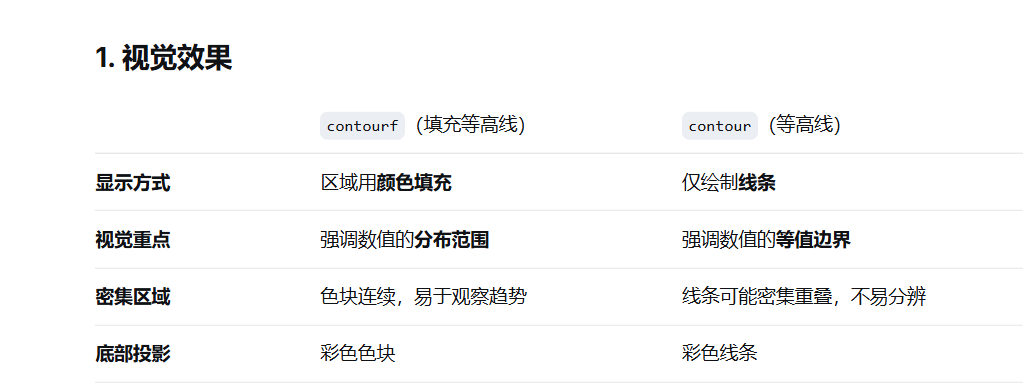

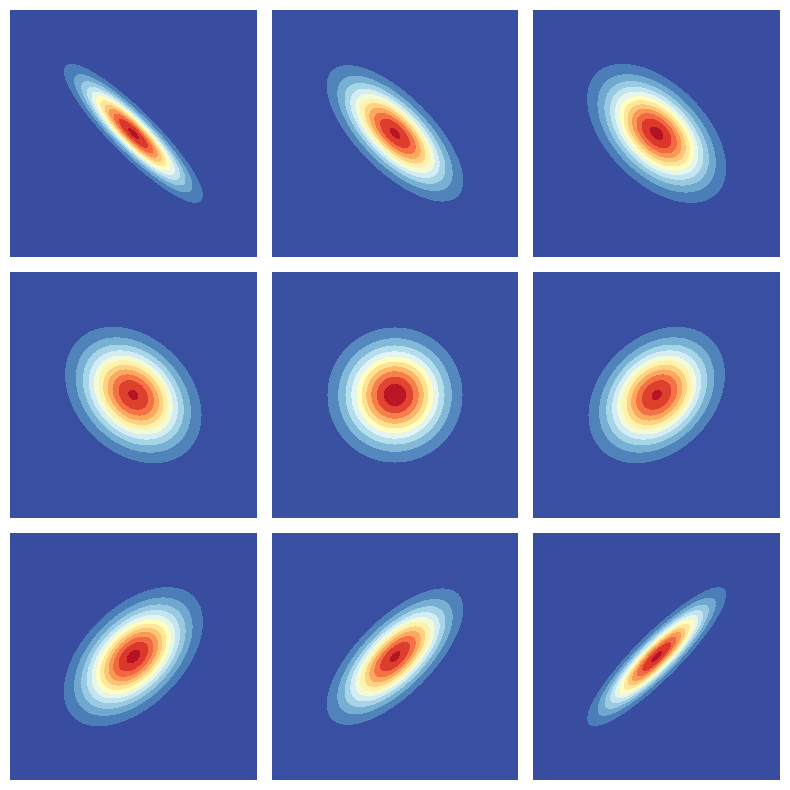

In [18]:
# 平面填充等高线
fig = plt.figure(figsize = (8,8))
for idx, rho_idx in enumerate(rho_array):
 mu = [mu_X, mu_Y]  #质心向量
 Sigma = [[sigma_X**2, sigma_X*sigma_Y*rho_idx], #协方差矩阵
 [sigma_X*sigma_Y*rho_idx, sigma_Y**2]]
 bi_norm = multivariate_normal(mu, Sigma)  #多元高数分布
 f_X_Y_joint = bi_norm.pdf(XXYY)  # 带入点得出值
 #每个二维数组变为一维数组；与第一层变为321,321
 #.pdf(XXYY)：一次性计算网格上所有点的概率密度值，返回形状为 (321, 321) 的矩阵

 ax = fig.add_subplot(3,3,idx+1)
 #contourf（填充等高线） 与上一个不同
 ax.contourf(XX, YY, f_X_Y_joint,
 levels = 12, cmap='RdYlBu_r')
 ax.set_xlabel('$x$') # 标签
 ax.set_ylabel('$y$')
 ax.set_xlim(-width, width) #范围
 ax.set_ylim(-width, width)
 ax.axis('off')

plt.tight_layout()
fig.savefig('二元高斯分布，等高线.svg', format='svg')
plt.show()


#等高线的结合f与r

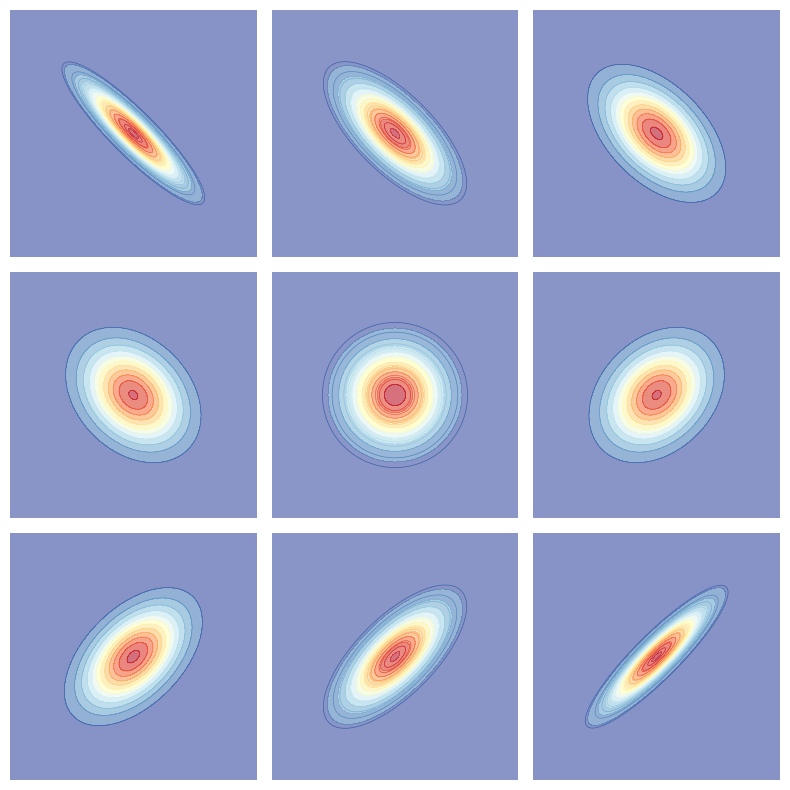

In [20]:
# 平面填充等高线
fig = plt.figure(figsize = (8,8))
for idx, rho_idx in enumerate(rho_array):
 mu = [mu_X, mu_Y]  #质心向量
 Sigma = [[sigma_X**2, sigma_X*sigma_Y*rho_idx], #协方差矩阵
 [sigma_X*sigma_Y*rho_idx, sigma_Y**2]]
 bi_norm = multivariate_normal(mu, Sigma)  #多元高数分布
 f_X_Y_joint = bi_norm.pdf(XXYY)  # 带入点得出值
 #每个二维数组变为一维数组；与第一层变为321,321
 #.pdf(XXYY)：一次性计算网格上所有点的概率密度值，返回形状为 (321, 321) 的矩阵

 ax = fig.add_subplot(3,3,idx+1)
 #contourf（填充等高线） 与上一个不同
 #ax.contourf(XX, YY, f_X_Y_joint,levels = 12, cmap='RdYlBu_r')
 ax.contourf(XX, YY, f_X_Y_joint, levels=12, cmap='RdYlBu_r', alpha=0.6)
 ax.contour(XX, YY, f_X_Y_joint, 15, cmap='RdYlBu_r', linewidths=0.5)

 ax.set_xlabel('$x$') # 标签
 ax.set_ylabel('$y$')
 ax.set_xlim(-width, width) #范围
 ax.set_ylim(-width, width)
 ax.axis('off')

plt.tight_layout()
fig.savefig('二元高斯分布，等高线.svg', format='svg')
plt.show()
